#### Bar mapping experiment for pRF

First load necessary libraries and initialize pgl

In [1]:
# autoload
%load_ext autoreload
%autoreload 2

# import necessary libraries
#import numpy as np

# Load PGL libraries and start PGL library
from pgl import pgl, pglExperiment, pglFixationTaskLeftRight, pglBarTask
pgl = pgl()

# close any existing windows
pgl.cleanUp()

================================ pglBase: init =================================
(pgl) mglMetal error log can be viewed in MacOS Console app by searching for PROCESS mglMetal or in a terminal with:
      log stream --level info --process mglMetal
(pgl) To search for something specifc, e.g. messages from mglMovie:
      log stream --predicate 'eventMessage CONTAINS "mglMovie"' --style syslog --level info
(pgl:checkOS) Python version: 3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:35:20) [Clang 16.0.6 ]
(pgl:checkOS) Running on MacBook Pro (MacBookPro18,3) with macOS version: 26.3.1
(pgl:checkOS) Apple M1 Pro Cores: 8 (6 Performance and 2 Efficiency) Memory: 32 GB
(pgl:checkOS) GPU: Apple M1 Pro (Built-In) 14 cores, Metal 4 support
(pgl:checkOS)   Color LCD [Main Display]: 3024 x 1964 Retina (Built-in Liquid Retina XDR Display) GammaTable size: 1024
(pglBase) Main library instance created
(pglBase:shutdownAll) Shutting down mglMetal process: 13062
(pglBase:removeOrphanedSocket

##### Display setting

In [ ]:
pgl.settings()

##### Setup the experiment and run

(pglSettingsManager:loadSettings) Loading settings from '/Users/justin/.pgl/settings/Main.json'.
(pglSettingsEditable:init) Loading settings from '/Users/justin/.pgl/settings/Main.json'.
================================= pglBase:open =================================
(pglBase:open) Starting mglMetal application: /Users/justin/Library/Developer/Xcode/DerivedData/Build/Products/Release/mglMetal.app
(pglBase:open) Using socket with address: /Users/justin/Library/Containers/gru.mglMetal/Data/pglMetal.socket.20260330_222145.T88ugcIKhE
(pgl:_pglComm) .Connected to: /Users/justin/Library/Containers/gru.mglMetal/Data/pglMetal.socket.20260330_222145.T88ugcIKhE
(pgl:_resolution:getResolution) Display 0/1: 1512x982 120Hz 32bits
(pglKeyboardMouse:start) Starting keyboard and mouse event listener.
(pglEventListener) Eating 7 keys: [18, 19, 20, 21, 49, 50, 53]
(pglBarTask) Total expected task time: 1 minutes 4.0 seconds, 64 volumes  (8 directions, 8.0 seconds/sweep, 8 volumes/sweep)
(pglExperiment:r

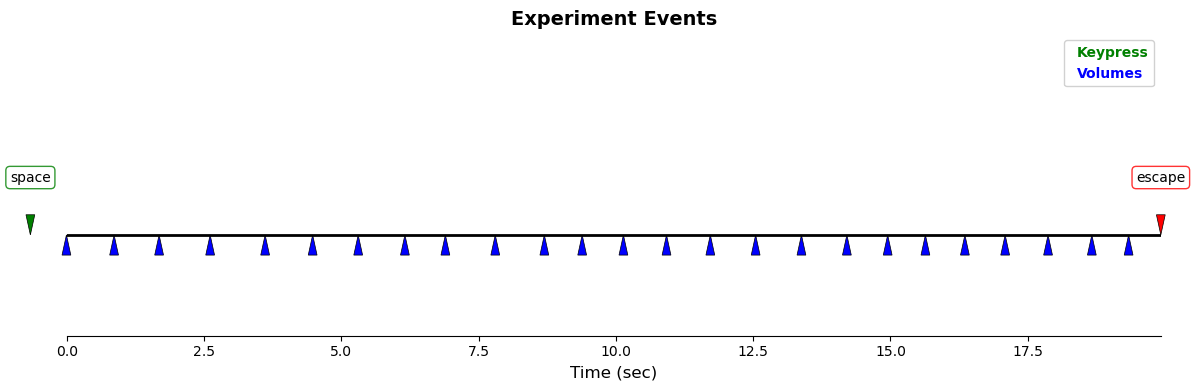

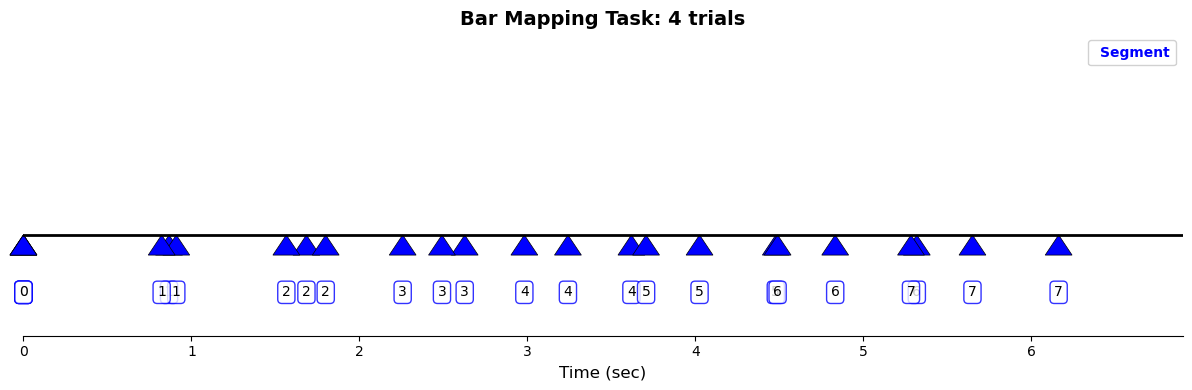

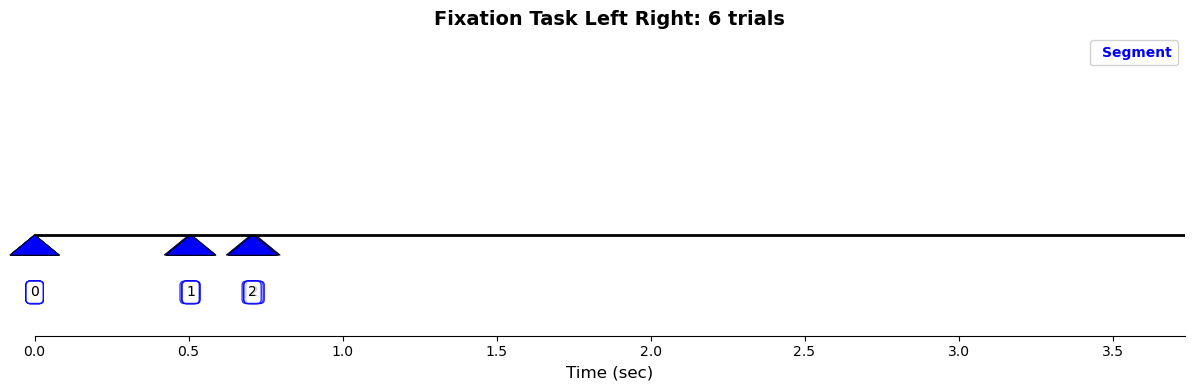

In [ ]:
# Set up experiment
e = pglExperiment(pgl, "Main", experimentName="pglBarTask")
e.initScreen()

# initialize tasks
fixationTask = pglFixationTaskLeftRight(pgl)
barTask = pglBarTask(pgl)

# add the tasks to the experiment
e.addTask(barTask)
e.addTask(fixationTask)

# and run the experiment
e.run()

# display results
e.display()

##### Load experiment

In [31]:
e = pglExperiment(experimentName="pglBarTask")

(pglExperiment) No settings provided, using default settings.
(pglExperiment:load) Data directory: /Users/justin/data/pglBarTask/s0000
Experiment name: pglBarTask | Subject ID: s0000
1. Friday March 20, 2026 12:51PM | nVols: 143 | 2 mins 27s | Default experiment (20260320_125144)
2. Friday March 20, 2026 12:55PM | nVols: 143 | 2 mins 25s | Default experiment (20260320_125515)
3. Friday March 20, 2026 12:58PM | nVols: 148 | 2 mins 29s | Bar mapping (20260320_125806)
4. Sunday March 22, 2026 2:22PM | nVols: 10 | 10s | pglTest (20260322_142223)
5. Thursday March 26, 2026 10:27AM | nVols: 0 | 4s | pglBarTask (20260326_102728)
6. Thursday March 26, 2026 10:28AM | nVols: 0 | 4s | pglBarTask (20260326_102810)
7. Thursday March 26, 2026 10:29AM | nVols: 0 | 2s | pglBarTask (20260326_102952)
8. Thursday March 26, 2026 10:30AM | nVols: 0 | 0s | pglBarTask (20260326_103040)
9. Thursday March 26, 2026 10:30AM | nVols: 0 | 0s | pglBarTask (20260326_103050)
10. Thursday March 26, 2026 10:31AM | nVol

##### Get stimulus images

In [32]:
# hacked for now = grab task settings and create a pglBarTask with the same settings
t = next((task for task in e.tasks if task.settings.taskName == "Bar Mapping Task"), None)
barTask = pglBarTask(pgl)
barTask.settings = t.settings
barTask.data = t.data
barTask.state = t.state
print(barTask.settings.taskName)
frames = barTask.getStimulusFrames(pgl, e.data.events, e.settings)

(pglBarTask) Total expected task time: 3 minutes 12.0 seconds, 192 volumes  (8 directions, 24.0 seconds/sweep, 24 volumes/sweep)
Bar Mapping Task
(pglBarTask:getStimulusFrames) Initializing bar stimulus with width=2, nVolumesPerSweep=24, sweepWidth=25, sweepHeight=25
(pglBarTask:getStimulusFrames) Capturing 240 frames
================================= pglBase:open =================================
(pglBase:open) Starting mglMetal application: /Users/justin/Library/Developer/Xcode/DerivedData/Build/Products/Release/mglMetal.app
(pglBase:open) Using socket with address: /Users/justin/Library/Containers/gru.mglMetal/Data/pglMetal.socket.20260330_222427.LWThyqPvBD
(pgl:_pglComm) .Connected to: /Users/justin/Library/Containers/gru.mglMetal/Data/pglMetal.socket.20260330_222427.LWThyqPvBD
(pgl:_resolution:getResolution) Display 0/1: 1512x982 120Hz 32bits
(pglImage:setRenderTarget) Setting render target to image 1 (800x600)
(pglBarTask:getStimulusFrames) Captured frame for dir=135 segmentNum =

##### Display stimulus images

In [ ]:
# display stimulus frames as a movie
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np

def showFramesJupyter(frames):
    """
    frames: numpy array with shape (numFrames, height, width, 4) - RGBA
    """
    
    numFrames = frames.shape[0]
    
    # Create output widget
    outputWidget = widgets.Output()
    
    # Create slider
    frameSlider = widgets.IntSlider(
        value=0,
        min=0,
        max=numFrames-1,
        description='Frame:',
        continuous_update=True,
        layout=widgets.Layout(width='400px')
    )
    
    # Create play button
    playButton = widgets.Play(
        value=0,
        min=0,
        max=numFrames-1,
        step=1,
        interval=100,
        description="Press play"
    )
    
    # Create increment/decrement buttons
    prevButton = widgets.Button(
        description='◀ Prev',
        button_style='',
        tooltip='Previous frame',
        icon='arrow-left'
    )
    
    nextButton = widgets.Button(
        description='Next ▶',
        button_style='',
        tooltip='Next frame',
        icon='arrow-right'
    )
    
    # Button click handlers
    def onPrevClick(b):
        if frameSlider.value > 0:
            frameSlider.value -= 1
    
    def onNextClick(b):
        if frameSlider.value < numFrames - 1:
            frameSlider.value += 1
    
    prevButton.on_click(onPrevClick)
    nextButton.on_click(onNextClick)
    
    # Link play button to slider
    widgets.jslink((playButton, 'value'), (frameSlider, 'value'))
    
    # Update function
    def updateFrame(change):
        with outputWidget:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(10, 7.5))
            ax.imshow(frames[change['new']])
            ax.set_title(f"Frame {change['new']} / {numFrames-1}")
            ax.axis('off')
            plt.tight_layout()
            plt.show()
            plt.close(fig)
    
    # Attach observer
    frameSlider.observe(updateFrame, names='value')
    
    # Layout widgets
    buttonBox = widgets.HBox([playButton, prevButton, nextButton])
    controlBox = widgets.VBox([buttonBox, frameSlider])
    
    display(controlBox)
    display(outputWidget)
    
    # Show first frame
    updateFrame({'new': 0})

# Usage
showFramesJupyter(frames)


Output()

In [ ]:
e.display()

##### Format and save to matlab

In [16]:
# format and save to .mat file (pRFStimImage.mat on Desktop)
import scipy.io
import numpy as np
import os

# Create copy and apply transformations
stimImage = frames.copy()

# Keep only first channel (R, drop GBA)
stimImage = stimImage[:, :, :, 0]

# Map values: 0.5 -> 0, everything else -> 1
stimImage = np.where(stimImage == 0.5, 0, 1)

# Flip left-right (horizontal flip)
stimImage = np.flip(stimImage, axis=2) 

# filepath
filepath = os.path.join(os.path.expanduser('~/Desktop'), 'pRFStimImage.mat')

# Save your frames array
scipy.io.savemat(filepath, { 'stimImage': stimImage })

KeyboardInterrupt: 

In [ ]:
print(e.data)